#**Problem Definition**

Laptop prices vary widely even among devices with similar specifications, making it difficult to determine the key factors that truly drive pricing. This project analyzes important features—such as RAM, CPU, storage, GPU, and brand—to identify their impact on price and uncover the main patterns behind these variations.

#Libraries

In [1]:
install.packages("pheatmap")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
install.packages("randomForest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
install.packages("e1071")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
library(tidyverse)
library(stringr)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Dataset

Dataset download link: https://www.kaggle.com/datasets/muhammetvarl/laptop-price/data

# Data Wrangling

## 1- Data discovering

In [5]:
# Read the dataset
df <- read.csv("/content/laptop_price (1).csv", fileEncoding = "latin1")

# Display first rows
head(df)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
3,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
4,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
5,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
6,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00


In [6]:
dim(df)

[1] 1303   13

In [7]:
str(df)

'data.frame':	1303 obs. of  13 variables:
 $ laptop_ID       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Company         : chr  "Apple" "Apple" "HP" "Apple" ...
 $ Product         : chr  "MacBook Pro" "Macbook Air" "250 G6" "MacBook Pro" ...
 $ TypeName        : chr  "Ultrabook" "Ultrabook" "Notebook" "Ultrabook" ...
 $ Inches          : num  13.3 13.3 15.6 15.4 13.3 15.6 15.4 13.3 14 14 ...
 $ ScreenResolution: chr  "IPS Panel Retina Display 2560x1600" "1440x900" "Full HD 1920x1080" "IPS Panel Retina Display 2880x1800" ...
 $ Cpu             : chr  "Intel Core i5 2.3GHz" "Intel Core i5 1.8GHz" "Intel Core i5 7200U 2.5GHz" "Intel Core i7 2.7GHz" ...
 $ Ram             : chr  "8GB" "8GB" "8GB" "16GB" ...
 $ Memory          : chr  "128GB SSD" "128GB Flash Storage" "256GB SSD" "512GB SSD" ...
 $ Gpu             : chr  "Intel Iris Plus Graphics 640" "Intel HD Graphics 6000" "Intel HD Graphics 620" "AMD Radeon Pro 455" ...
 $ OpSys           : chr  "macOS" "macOS" "No OS" "macOS" ...
 $ Weight      

In [8]:
df %>%
  count(Company, sort = TRUE)

Company,n
<chr>,<int>
Dell,297
Lenovo,297
HP,274
Asus,158
Acer,103
MSI,54
Toshiba,48
Apple,21
Samsung,9


In [9]:
# Statistical description of numerical data
numeric_df <- df[sapply(df, is.numeric)]
summary(numeric_df)

   laptop_ID          Inches       Price_euros  
 Min.   :   1.0   Min.   :10.10   Min.   : 174  
 1st Qu.: 331.5   1st Qu.:14.00   1st Qu.: 599  
 Median : 659.0   Median :15.60   Median : 977  
 Mean   : 660.2   Mean   :15.02   Mean   :1124  
 3rd Qu.: 990.5   3rd Qu.:15.60   3rd Qu.:1488  
 Max.   :1320.0   Max.   :18.40   Max.   :6099  

In [10]:
# Statistical description of categorical data
categorical_df <- df[sapply(df, function(x) is.character(x) || is.factor(x))]
summary(categorical_df)

   Company            Product            TypeName         ScreenResolution  
 Length:1303        Length:1303        Length:1303        Length:1303       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
     Cpu                Ram               Memory              Gpu           
 Length:1303        Length:1303        Length:1303        Length:1303       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
    OpSys              Weight         
 Length:1303        Length:1303       
 Class :character   Class :character  
 Mode  :character   Mode  :character  

## 2- Data Cleaning


In [11]:
df %>%
  summarise(across(everything(), ~ sum(is.na(.))))

laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
remove_dups <- function(df) {
  dups <- sum(duplicated(df))

  if (dups > 0) {
    cat("duplicated values:", dups, "\n")

    # Remove duplicates
    df <- unique(df)
  } else {
    cat("There is 0 duplicates\n")
  }

  return(df)
}

# Call the function
df <- remove_dups(df)

There is 0 duplicates


## 3- Data Enriching

In [13]:
unique(df$Cpu)

[1] "Intel Core i5 2.3GHz"                 
  [2] "Intel Core i5 1.8GHz"                 
  [3] "Intel Core i5 7200U 2.5GHz"           
  [4] "Intel Core i7 2.7GHz"                 
  [5] "Intel Core i5 3.1GHz"                 
  [6] "AMD A9-Series 9420 3GHz"              
  [7] "Intel Core i7 2.2GHz"                 
  [8] "Intel Core i7 8550U 1.8GHz"           
  [9] "Intel Core i5 8250U 1.6GHz"           
 [10] "Intel Core i3 6006U 2GHz"             
 [11] "Intel Core i7 2.8GHz"                 
 [12] "Intel Core M m3 1.2GHz"               
 [13] "Intel Core i7 7500U 2.7GHz"           
 [14] "Intel Core i7 2.9GHz"                 
 [15] "Intel Core i3 7100U 2.4GHz"           
 [16] "Intel Atom x5-Z8350 1.44GHz"          
 [17] "Intel Core i5 7300HQ 2.5GHz"          
 [18] "AMD E-Series E2-9000e 1.5GHz"         
 [19] "Intel Core i5 1.6GHz"                 
 [20] "Intel Core i7 8650U 1.9GHz"           
 [21] "Intel Atom x5-Z8300 1.44GHz"          
 [22] "AMD E-Series E2-6110 1.5GHz"          
 [23] "AMD A6-Series 9220 2.5GHz"            
 [24] "Intel Celeron Dual Core N3350 1.1GHz" 
 [25] "Intel Core i3 7130U 2.7GHz"           
 [26] "Intel Core i7 7700HQ 2.8GHz"          
 [27] "Intel Core i5 2.0GHz"                 
 [28] "AMD Ryzen 1700 3GHz"                  
 [29] "Intel Pentium Quad Core N4200 1.1GHz" 
 [30] "Intel Atom x5-Z8550 1.44GHz"          
 [31] "Intel Celeron Dual Core N3060 1.6GHz" 
 [32] "Intel Core i5 1.3GHz"                 
 [33] "AMD FX 9830P 3GHz"                    
 [34] "Intel Core i7 7560U 2.4GHz"           
 [35] "AMD E-Series 6110 1.5GHz"             
 [36] "Intel Core i5 6200U 2.3GHz"           
 [37] "Intel Core M 6Y75 1.2GHz"             
 [38] "Intel Core i5 7500U 2.7GHz"           
 [39] "Intel Core i3 6006U 2.2GHz"           
 [40] "AMD A6-Series 9220 2.9GHz"            
 [41] "Intel Core i7 6920HQ 2.9GHz"          
 [42] "Intel Core i5 7Y54 1.2GHz"            
 [43] "Intel Core i7 7820HK 2.9GHz"          
 [44] "Intel Xeon E3-1505M V6 3GHz"          
 [45] "Intel Core i7 6500U 2.5GHz"           
 [46] "AMD E-Series 9000e 1.5GHz"            
 [47] "AMD A10-Series A10-9620P 2.5GHz"      
 [48] "AMD A6-Series A6-9220 2.5GHz"         
 [49] "Intel Core i5 2.9GHz"                 
 [50] "Intel Core i7 6600U 2.6GHz"           
 [51] "Intel Core i3 6006U 2.0GHz"           
 [52] "Intel Celeron Dual Core 3205U 1.5GHz" 
 [53] "Intel Core i7 7820HQ 2.9GHz"          
 [54] "AMD A10-Series 9600P 2.4GHz"          
 [55] "Intel Core i7 7600U 2.8GHz"           
 [56] "AMD A8-Series 7410 2.2GHz"            
 [57] "Intel Celeron Dual Core 3855U 1.6GHz" 
 [58] "Intel Pentium Quad Core N3710 1.6GHz" 
 [59] "AMD A12-Series 9720P 2.7GHz"          
 [60] "Intel Core i5 7300U 2.6GHz"           
 [61] "AMD A12-Series 9720P 3.6GHz"          
 [62] "Intel Celeron Quad Core N3450 1.1GHz" 
 [63] "Intel Celeron Dual Core N3060 1.60GHz"
 [64] "Intel Core i5 6440HQ 2.6GHz"          
 [65] "Intel Core i7 6820HQ 2.7GHz"          
 [66] "AMD Ryzen 1600 3.2GHz"                
 [67] "Intel Core i7 7Y75 1.3GHz"            
 [68] "Intel Core i5 7440HQ 2.8GHz"          
 [69] "Intel Core i7 7660U 2.5GHz"           
 [70] "Intel Core i7 7700HQ 2.7GHz"          
 [71] "Intel Core M m3-7Y30 2.2GHz"          
 [72] "Intel Core i5 7Y57 1.2GHz"            
 [73] "Intel Core i7 6700HQ 2.6GHz"          
 [74] "Intel Core i3 6100U 2.3GHz"           
 [75] "AMD A10-Series 9620P 2.5GHz"          
 [76] "AMD E-Series 7110 1.8GHz"             
 [77] "Intel Celeron Dual Core N3350 2.0GHz" 
 [78] "AMD A9-Series A9-9420 3GHz"           
 [79] "Intel Core i7 6820HK 2.7GHz"          
 [80] "Intel Core M 7Y30 1.0GHz"             
 [81] "Intel Xeon E3-1535M v6 3.1GHz"        
 [82] "Intel Celeron Quad Core N3160 1.6GHz" 
 [83] "Intel Core i5 6300U 2.4GHz"           
 [84] "Intel Core i3 6100U 2.1GHz"           
 [85] "AMD E-Series E2-9000 2.2GHz"          
 [86] "Intel Celeron Dual Core N3050 1.6GHz" 
 [87] "Intel Core M M3-6Y30 0.9GHz"          


In [14]:
extract_cpu_info <- function(cpu_string) {

  parts_cpu <- strsplit(cpu_string, " ")[[1]]

  cpu_company <- parts_cpu[1]
  cpu <- paste(parts_cpu[2:(length(parts_cpu) - 1)], collapse = " ")
  frequency <- gsub("GHz", "", parts_cpu[length(parts_cpu)])

  frequency <- suppressWarnings(as.numeric(frequency))

  return(c(cpu_company, cpu, frequency))
}

cpu_info <- t(sapply(df$Cpu, extract_cpu_info))

df$Cpu_Company <- cpu_info[,1]
df$Cpu_Type <- cpu_info[,2]
df$Cpu_Freq_GHz <- as.numeric(cpu_info[,3])

In [15]:
head(df)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq_GHz
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
1,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,Intel,Core i5,2.3
2,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,Intel,Core i5,1.8
3,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,Intel,Core i5 7200U,2.5
4,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,Intel,Core i7,2.7
5,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,Intel,Core i5,3.1
6,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00,AMD,A9-Series 9420,3.0


In [16]:
unique(df$Cpu_Type)

[1] "Core i5"                 "Core i5 7200U"          
 [3] "Core i7"                 "A9-Series 9420"         
 [5] "Core i7 8550U"           "Core i5 8250U"          
 [7] "Core i3 6006U"           "Core M m3"              
 [9] "Core i7 7500U"           "Core i3 7100U"          
[11] "Atom x5-Z8350"           "Core i5 7300HQ"         
[13] "E-Series E2-9000e"       "Core i7 8650U"          
[15] "Atom x5-Z8300"           "E-Series E2-6110"       
[17] "A6-Series 9220"          "Celeron Dual Core N3350"
[19] "Core i3 7130U"           "Core i7 7700HQ"         
[21] "Ryzen 1700"              "Pentium Quad Core N4200"
[23] "Atom x5-Z8550"           "Celeron Dual Core N3060"
[25] "FX 9830P"                "Core i7 7560U"          
[27] "E-Series 6110"           "Core i5 6200U"          
[29] "Core M 6Y75"             "Core i5 7500U"          
[31] "Core i7 6920HQ"          "Core i5 7Y54"           
[33] "Core i7 7820HK"          "Xeon E3-1505M V6"       
[35] "Core i7 6500U"           "E-Series 9000e"         
[37] "A10-Series A10-9620P"    "A6-Series A6-9220"      
[39] "Core i7 6600U"           "Celeron Dual Core 3205U"
[41] "Core i7 7820HQ"          "A10-Series 9600P"       
[43] "Core i7 7600U"           "A8-Series 7410"         
[45] "Celeron Dual Core 3855U" "Pentium Quad Core N3710"
[47] "A12-Series 9720P"        "Core i5 7300U"          
[49] "Celeron Quad Core N3450" "Core i5 6440HQ"         
[51] "Core i7 6820HQ"          "Ryzen 1600"             
[53] "Core i7 7Y75"            "Core i5 7440HQ"         
[55] "Core i7 7660U"           "Core M m3-7Y30"         
[57] "Core i5 7Y57"            "Core i7 6700HQ"         
[59] "Core i3 6100U"           "A10-Series 9620P"       
[61] "E-Series 7110"           "A9-Series A9-9420"      
[63] "Core i7 6820HK"          "Core M 7Y30"            
[65] "Xeon E3-1535M v6"        "Celeron Quad Core N3160"
[67] "Core i5 6300U"           "E-Series E2-9000"       
[69] "Celeron Dual Core N3050" "Core M M3-6Y30"         
[71] "Core i5 6300HQ"          "A6-Series 7310"         
[73] "Atom Z8350"              "Xeon E3-1535M v5"       
[75] "Core i5 6260U"           "Pentium Dual Core N4200"
[77] "Celeron Quad Core N3710" "Core M"                 
[79] "A12-Series 9700P"        "Pentium Dual Core 4405U"
[81] "A4-Series 7210"          "Core i7 6560U"          
[83] "Core M m7-6Y75"          "FX 8800P"               
[85] "Core M M7-6Y75"          "Atom X5-Z8350"          
[87] "Pentium Dual Core 4405Y" "Pentium Quad Core N3700"
[89] "Core M 6Y54"             "Cortex A72&A53"         
[91] "E-Series 9000"           "Core M 6Y30"            
[93] "A9-Series 9410"

In [17]:
df %>%
  count(Cpu_Type, sort = TRUE)

Cpu_Type,n
<chr>,<int>
Core i5 7200U,193
Core i7 7700HQ,147
Core i7 7500U,135
Core i3 6006U,81
Core i7 8550U,73
Core i5 8250U,72
Core i5 6200U,68
Core i7 6500U,51
Core i7 6700HQ,43


In [18]:
df %>%
  count(Cpu_Company, sort = TRUE)

Cpu_Company,n
<chr>,<int>
Intel,1240
AMD,62
Samsung,1


In [19]:
df[df$Cpu_Company == "Samsung", ]

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq_GHz
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
1192,1209,Samsung,Chromebook Plus,2 in 1 Convertible,12.3,IPS Panel Touchscreen 2400x1600,Samsung Cortex A72&A53 2.0GHz,4GB,32GB Flash Storage,ARM Mali T860 MP4,Chrome OS,1.15kg,659,Samsung,Cortex A72&A53,2


In [20]:
df <- df[-1192, ]

In [21]:
df[df$Cpu_Company == "Samsung", ]

laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq_GHz
<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>


In [22]:
unique(df$Gpu)

[1] "Intel Iris Plus Graphics 640"   "Intel HD Graphics 6000"        
  [3] "Intel HD Graphics 620"          "AMD Radeon Pro 455"            
  [5] "Intel Iris Plus Graphics 650"   "AMD Radeon R5"                 
  [7] "Intel Iris Pro Graphics"        "Nvidia GeForce MX150"          
  [9] "Intel UHD Graphics 620"         "Intel HD Graphics 520"         
 [11] "AMD Radeon Pro 555"             "AMD Radeon R5 M430"            
 [13] "Intel HD Graphics 615"          "AMD Radeon Pro 560"            
 [15] "Nvidia GeForce 940MX"           "Intel HD Graphics 400"         
 [17] "Nvidia GeForce GTX 1050"        "AMD Radeon R2"                 
 [19] "AMD Radeon 530"                 "Nvidia GeForce 930MX"          
 [21] "Intel HD Graphics"              "Intel HD Graphics 500"         
 [23] "Nvidia GeForce 930MX "          "Nvidia GeForce GTX 1060"       
 [25] "Nvidia GeForce 150MX"           "Intel Iris Graphics 540"       
 [27] "AMD Radeon RX 580"              "Nvidia GeForce 920MX"          
 [29] "AMD Radeon R4 Graphics"         "AMD Radeon 520"                
 [31] "Nvidia GeForce GTX 1070"        "Nvidia GeForce GTX 1050 Ti"    
 [33] "Nvidia GeForce MX130"           "AMD R4 Graphics"               
 [35] "Nvidia GeForce GTX 940MX"       "AMD Radeon RX 560"             
 [37] "Nvidia GeForce 920M"            "AMD Radeon R7 M445"            
 [39] "AMD Radeon RX 550"              "Nvidia GeForce GTX 1050M"      
 [41] "Intel HD Graphics 515"          "AMD Radeon R5 M420"            
 [43] "Intel HD Graphics 505"          "Nvidia GTX 980 SLI"            
 [45] "AMD R17M-M1-70"                 "Nvidia GeForce GTX 1080"       
 [47] "Nvidia Quadro M1200"            "Nvidia GeForce 920MX "         
 [49] "Nvidia GeForce GTX 950M"        "AMD FirePro W4190M "           
 [51] "Nvidia GeForce GTX 980M"        "Intel Iris Graphics 550"       
 [53] "Nvidia GeForce 930M"            "Intel HD Graphics 630"         
 [55] "AMD Radeon R5 430"              "Nvidia GeForce GTX 940M"       
 [57] "Intel HD Graphics 510"          "Intel HD Graphics 405"         
 [59] "AMD Radeon RX 540"              "Nvidia GeForce GT 940MX"       
 [61] "AMD FirePro W5130M"             "Nvidia Quadro M2200M"          
 [63] "AMD Radeon R4"                  "Nvidia Quadro M620"            
 [65] "AMD Radeon R7 M460"             "Intel HD Graphics 530"         
 [67] "Nvidia GeForce GTX 965M"        "Nvidia GeForce GTX1080"        
 [69] "Nvidia GeForce GTX1050 Ti"      "Nvidia GeForce GTX 960M"       
 [71] "AMD Radeon R2 Graphics"         "Nvidia Quadro M620M"           
 [73] "Nvidia GeForce GTX 970M"        "Nvidia GeForce GTX 960<U+039C>"
 [75] "Intel Graphics 620"             "Nvidia GeForce GTX 960"        
 [77] "AMD Radeon R5 520"              "AMD Radeon R7 M440"            
 [79] "AMD Radeon R7"                  "Nvidia Quadro M520M"           
 [81] "Nvidia Quadro M2200"            "Nvidia Quadro M2000M"          
 [83] "Intel HD Graphics 540"          "Nvidia Quadro M1000M"          
 [85] "AMD Radeon 540"                 "Nvidia GeForce GTX 1070M"      
 [87] "Nvidia GeForce GTX1060"         "Intel HD Graphics 5300"        
 [89] "AMD Radeon R5 M420X"            "AMD Radeon R7 Graphics"        
 [91] "Nvidia GeForce 920"             "Nvidia GeForce 940M"           
 [93] "Nvidia GeForce GTX 930MX"       "AMD Radeon R7 M465"            
 [95] "AMD Radeon R3"                  "Nvidia GeForce GTX 1050Ti"     
 [97] "AMD Radeon R7 M365X"            "AMD Radeon R9 M385"            
 [99] "Intel HD Graphics 620 "         "Nvidia Quadro 3000M"           
[101] "Nvidia GeForce GTX 980 "        "AMD Radeon R5 M330"            
[103] "AMD FirePro W4190M"             "AMD FirePro W6150M"            
[105] "AMD Radeon R5 M315"             "Nvidia Quadro M500M"           
[107] "AMD Radeon R7 M360"             "Nvidia Quadro M3000M"          
[109] "Nvidia GeForce 960M"

In [23]:
extract_GPU_info <- function(df) {

  # Extract GPU company (first word)
  df$Gpu_company <- sub("^\\w+", "", df$Gpu)
  df$Gpu_company <- sub("^\\s+", "", df$Gpu_company)  # clean leading space

  df$Gpu_company <- sub(" .*", "", df$Gpu)  # correct extraction version

  # Extract GPU type (everything after first word)
  df$Gpu_Type <- sub("^\\w+\\s*", "", df$Gpu)

  # Drop original column
  df$Gpu <- NULL

  return(df)
}

df <- extract_GPU_info(df)

In [24]:
head(df)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,Gpu_company,Gpu_Type
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,macOS,1.37kg,1339.69,Intel,Core i5,2.3,Intel,Iris Plus Graphics 640
2,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,macOS,1.34kg,898.94,Intel,Core i5,1.8,Intel,HD Graphics 6000
3,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,No OS,1.86kg,575.00,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620
4,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,macOS,1.83kg,2537.45,Intel,Core i7,2.7,AMD,Radeon Pro 455
5,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,macOS,1.37kg,1803.60,Intel,Core i5,3.1,Intel,Iris Plus Graphics 650
6,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,Windows 10,2.1kg,400.00,AMD,A9-Series 9420,3.0,AMD,Radeon R5


In [25]:
df %>%
  count(Gpu_company, sort = TRUE)

Gpu_company,n
<chr>,<int>
Intel,722
Nvidia,400
AMD,180


In [26]:
df %>%
  count(Gpu_Type, sort = TRUE)

Gpu_Type,n
<chr>,<int>
HD Graphics 620,281
HD Graphics 520,185
UHD Graphics 620,68
GeForce GTX 1050,66
GeForce GTX 1060,48
GeForce 940MX,43
Radeon 530,41
HD Graphics 500,39
HD Graphics 400,37


In [27]:
unique(df$Memory)

[1] "128GB SSD"                     "128GB Flash Storage"          
 [3] "256GB SSD"                     "512GB SSD"                    
 [5] "500GB HDD"                     "256GB Flash Storage"          
 [7] "1TB HDD"                       "32GB Flash Storage"           
 [9] "128GB SSD +  1TB HDD"          "256GB SSD +  256GB SSD"       
[11] "64GB Flash Storage"            "256GB SSD +  1TB HDD"         
[13] "256GB SSD +  2TB HDD"          "32GB SSD"                     
[15] "2TB HDD"                       "64GB SSD"                     
[17] "1.0TB Hybrid"                  "512GB SSD +  1TB HDD"         
[19] "1TB SSD"                       "256GB SSD +  500GB HDD"       
[21] "128GB SSD +  2TB HDD"          "512GB SSD +  512GB SSD"       
[23] "16GB SSD"                      "16GB Flash Storage"           
[25] "512GB SSD +  256GB SSD"        "512GB SSD +  2TB HDD"         
[27] "64GB Flash Storage +  1TB HDD" "180GB SSD"                    
[29] "1TB HDD +  1TB HDD"            "32GB HDD"                     
[31] "1TB SSD +  1TB HDD"            "512GB Flash Storage"          
[33] "128GB HDD"                     "240GB SSD"                    
[35] "8GB SSD"                       "508GB Hybrid"                 
[37] "1.0TB HDD"                     "512GB SSD +  1.0TB Hybrid"    
[39] "256GB SSD +  1.0TB Hybrid"

In [28]:
extract_Memory_info <- function(Memory_string) {

  parts_memory <- strsplit(Memory_string, "\\+")[[1]]

  First_memory <- parts_memory[1]

  if (length(parts_memory) > 1) {
    Second_memory <- trimws(parts_memory[2])
  } else {
    Second_memory <- NA
  }

  return(c(First_memory, Second_memory))
}

memory_info <- t(sapply(df$Memory, extract_Memory_info))

df$First_memory <- memory_info[,1]
df$Second_memory <- memory_info[,2]

In [29]:
head(df)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,OpSys,Weight,Price_euros,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,Gpu_company,Gpu_Type,First_memory,Second_memory
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,macOS,1.37kg,1339.69,Intel,Core i5,2.3,Intel,Iris Plus Graphics 640,128GB SSD,NA
2,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,macOS,1.34kg,898.94,Intel,Core i5,1.8,Intel,HD Graphics 6000,128GB Flash Storage,NA
3,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,No OS,1.86kg,575.00,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,256GB SSD,NA
4,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,macOS,1.83kg,2537.45,Intel,Core i7,2.7,AMD,Radeon Pro 455,512GB SSD,NA
5,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,macOS,1.37kg,1803.60,Intel,Core i5,3.1,Intel,Iris Plus Graphics 650,256GB SSD,NA
6,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,Windows 10,2.1kg,400.00,AMD,A9-Series 9420,3.0,AMD,Radeon R5,500GB HDD,NA


In [30]:
df$Cpu <- NULL
df$Gpu <- NULL
df$Memory <- NULL

In [31]:
new_order <- c('laptop_ID', 'Company', 'Product', 'TypeName', 'Inches','ScreenResolution','Cpu_Company', 'Cpu_Type', 'Cpu_Freq_GHz',
               'Ram','First_memory','Second_memory','Gpu_company','Gpu_Type','OpSys', 'Weight','Price_euros')

df <- df[, new_order]
head(df)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,Ram,First_memory,Second_memory,Gpu_company,Gpu_Type,OpSys,Weight,Price_euros
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8GB,128GB SSD,NA,Intel,Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8GB,128GB Flash Storage,NA,Intel,HD Graphics 6000,macOS,1.34kg,898.94
3,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8GB,256GB SSD,NA,Intel,HD Graphics 620,No OS,1.86kg,575.00
4,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16GB,512GB SSD,NA,AMD,Radeon Pro 455,macOS,1.83kg,2537.45
5,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8GB,256GB SSD,NA,Intel,Iris Plus Graphics 650,macOS,1.37kg,1803.60
6,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4GB,500GB HDD,NA,AMD,Radeon R5,Windows 10,2.1kg,400.00


In [32]:
df %>%
  count(First_memory, sort = TRUE)

First_memory,n
<chr>,<int>
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD,96
256GB SSD,88
128GB SSD,76
32GB Flash Storage,37
512GB SSD,20


In [33]:
df %>%
  count(Second_memory, sort = TRUE)

Second_memory,n
<chr>,<int>
NA,1094
1TB HDD,185
2TB HDD,15
256GB SSD,3
1.0TB Hybrid,2
500GB HDD,2
512GB SSD,1


In [34]:
extract_fMemory_info <- function(fMemory_string) {

  fparts_memory <- strsplit(fMemory_string, " ")[[1]]

  First_memory_volume <- fparts_memory[1]
  First_memory_type <- paste(fparts_memory[-1], collapse = " ")

  return(c(First_memory_volume, First_memory_type))
}

first_memory_info <- t(sapply(df$First_memory, extract_fMemory_info))

df$First_memory_volume <- first_memory_info[,1]
df$First_memory_type <- first_memory_info[,2]

In [35]:
extract_SMemory_info <- function(SMemory_string) {

  if (is.na(SMemory_string)) {
    return(c(NA, NA))
  }

  Sparts_memory <- strsplit(SMemory_string, " ")[[1]]

  Second_memory_volume <- Sparts_memory[1]
  Second_memory_type <- paste(Sparts_memory[-1], collapse = " ")

  return(c(Second_memory_volume, Second_memory_type))
}

second_memory_info <- t(sapply(df$Second_memory, extract_SMemory_info))

df$Second_memory_volume <- second_memory_info[,1]
df$Second_memory_type <- second_memory_info[,2]

In [36]:
new_order <- c('laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
               'ScreenResolution',
               'Cpu_Company', 'Cpu_Type', 'Cpu_Freq_GHz',
               'Ram',
               'First_memory_volume','First_memory_type',
               'Second_memory_volume','Second_memory_type',
               'Gpu_company','Gpu_Type',
               'OpSys', 'Weight','Price_euros')

df <- df[, new_order]

head(df)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,Ram,First_memory_volume,First_memory_type,Second_memory_volume,Second_memory_type,Gpu_company,Gpu_Type,OpSys,Weight,Price_euros
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8GB,128GB,SSD,NA,NA,Intel,Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8GB,128GB,Flash Storage,NA,NA,Intel,HD Graphics 6000,macOS,1.34kg,898.94
3,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8GB,256GB,SSD,NA,NA,Intel,HD Graphics 620,No OS,1.86kg,575.00
4,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16GB,512GB,SSD,NA,NA,AMD,Radeon Pro 455,macOS,1.83kg,2537.45
5,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8GB,256GB,SSD,NA,NA,Intel,Iris Plus Graphics 650,macOS,1.37kg,1803.60
6,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4GB,500GB,HDD,NA,NA,AMD,Radeon R5,Windows 10,2.1kg,400.00


In [37]:
str(df)

'data.frame':	1302 obs. of  19 variables:
 $ laptop_ID           : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Company             : chr  "Apple" "Apple" "HP" "Apple" ...
 $ Product             : chr  "MacBook Pro" "Macbook Air" "250 G6" "MacBook Pro" ...
 $ TypeName            : chr  "Ultrabook" "Ultrabook" "Notebook" "Ultrabook" ...
 $ Inches              : num  13.3 13.3 15.6 15.4 13.3 15.6 15.4 13.3 14 14 ...
 $ ScreenResolution    : chr  "IPS Panel Retina Display 2560x1600" "1440x900" "Full HD 1920x1080" "IPS Panel Retina Display 2880x1800" ...
 $ Cpu_Company         : chr  "Intel" "Intel" "Intel" "Intel" ...
 $ Cpu_Type            : chr  "Core i5" "Core i5" "Core i5 7200U" "Core i7" ...
 $ Cpu_Freq_GHz        : num  2.3 1.8 2.5 2.7 3.1 3 2.2 1.8 1.8 1.6 ...
 $ Ram                 : chr  "8GB" "8GB" "8GB" "16GB" ...
 $ First_memory_volume : chr  "128GB" "128GB" "256GB" "512GB" ...
 $ First_memory_type   : chr  "SSD" "Flash Storage" "SSD" "SSD" ...
 $ Second_memory_volume: chr  NA NA NA NA ..

In [38]:
unique(df$Second_memory_volume)

[1] NA      "1TB"   "256GB" "2TB"   "500GB" "512GB" "1.0TB"

In [39]:
unique(df$Second_memory_type)

[1] NA       "HDD"    "SSD"    "Hybrid"

In [40]:
sum(is.na(df$Second_memory_type))

[1] 1094

##### Note: Due to the high number of missing values because not all laptops have a secondary hard drive, We will be dropping this column

In [41]:
df$Second_memory_type <- NULL

In [42]:
convert_to_gb1 <- function(x) {

  if (grepl("TB", x)) {
    return(as.numeric(trimws(gsub("TB", "", x))) * 1024)
  }

  if (grepl("GB", x)) {
    return(as.numeric(trimws(gsub("GB", "", x))))
  }

  return(NA)
}

df$First_memory_volume <- sapply(df$First_memory_volume, convert_to_gb1)

In [43]:
convert_to_gb2 <- function(x) {

  if (is.na(x)) {
    return(0)
  }

  if (grepl("TB", x)) {
    return(as.numeric(trimws(gsub("TB", "", x))) * 1024)
  }

  if (grepl("GB", x)) {
    return(as.numeric(trimws(gsub("GB", "", x))))
  }

  return(NA)
}

df$Second_memory_volume <- sapply(df$Second_memory_volume, convert_to_gb2)

In [44]:
names(df)[names(df) == "First_memory_volume"] <- "First_memory_volume_GB"
names(df)[names(df) == "Second_memory_volume"] <- "Second_memory_volume_GB"

In [45]:
head(df)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,Ram,First_memory_volume_GB,First_memory_type,Second_memory_volume_GB,Gpu_company,Gpu_Type,OpSys,Weight,Price_euros
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8GB,128,SSD,0,Intel,Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8GB,128,Flash Storage,0,Intel,HD Graphics 6000,macOS,1.34kg,898.94
3,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8GB,256,SSD,0,Intel,HD Graphics 620,No OS,1.86kg,575.00
4,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16GB,512,SSD,0,AMD,Radeon Pro 455,macOS,1.83kg,2537.45
5,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8GB,256,SSD,0,Intel,Iris Plus Graphics 650,macOS,1.37kg,1803.60
6,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4GB,500,HDD,0,AMD,Radeon R5,Windows 10,2.1kg,400.00


In [46]:
str(df)

'data.frame':	1302 obs. of  18 variables:
 $ laptop_ID              : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Company                : chr  "Apple" "Apple" "HP" "Apple" ...
 $ Product                : chr  "MacBook Pro" "Macbook Air" "250 G6" "MacBook Pro" ...
 $ TypeName               : chr  "Ultrabook" "Ultrabook" "Notebook" "Ultrabook" ...
 $ Inches                 : num  13.3 13.3 15.6 15.4 13.3 15.6 15.4 13.3 14 14 ...
 $ ScreenResolution       : chr  "IPS Panel Retina Display 2560x1600" "1440x900" "Full HD 1920x1080" "IPS Panel Retina Display 2880x1800" ...
 $ Cpu_Company            : chr  "Intel" "Intel" "Intel" "Intel" ...
 $ Cpu_Type               : chr  "Core i5" "Core i5" "Core i5 7200U" "Core i7" ...
 $ Cpu_Freq_GHz           : num  2.3 1.8 2.5 2.7 3.1 3 2.2 1.8 1.8 1.6 ...
 $ Ram                    : chr  "8GB" "8GB" "8GB" "16GB" ...
 $ First_memory_volume_GB : num  128 128 256 512 256 500 256 256 512 256 ...
 $ First_memory_type      : chr  "SSD" "Flash Storage" "SSD" "SSD" ...


In [47]:
unique(df$ScreenResolution)

[1] "IPS Panel Retina Display 2560x1600"           
 [2] "1440x900"                                     
 [3] "Full HD 1920x1080"                            
 [4] "IPS Panel Retina Display 2880x1800"           
 [5] "1366x768"                                     
 [6] "IPS Panel Full HD 1920x1080"                  
 [7] "IPS Panel Retina Display 2304x1440"           
 [8] "IPS Panel Full HD / Touchscreen 1920x1080"    
 [9] "Full HD / Touchscreen 1920x1080"              
[10] "Touchscreen / Quad HD+ 3200x1800"             
[11] "IPS Panel Touchscreen 1920x1200"              
[12] "Touchscreen 2256x1504"                        
[13] "Quad HD+ / Touchscreen 3200x1800"             
[14] "IPS Panel 1366x768"                           
[15] "IPS Panel 4K Ultra HD / Touchscreen 3840x2160"
[16] "IPS Panel Full HD 2160x1440"                  
[17] "4K Ultra HD / Touchscreen 3840x2160"          
[18] "Touchscreen 2560x1440"                        
[19] "1600x900"                                     
[20] "IPS Panel 4K Ultra HD 3840x2160"              
[21] "4K Ultra HD 3840x2160"                        
[22] "Touchscreen 1366x768"                         
[23] "IPS Panel Full HD 1366x768"                   
[24] "IPS Panel 2560x1440"                          
[25] "IPS Panel Full HD 2560x1440"                  
[26] "IPS Panel Retina Display 2736x1824"           
[27] "Touchscreen 2400x1600"                        
[28] "2560x1440"                                    
[29] "IPS Panel Quad HD+ 2560x1440"                 
[30] "IPS Panel Quad HD+ 3200x1800"                 
[31] "IPS Panel Quad HD+ / Touchscreen 3200x1800"   
[32] "IPS Panel Touchscreen 1366x768"               
[33] "1920x1080"                                    
[34] "IPS Panel Full HD 1920x1200"                  
[35] "IPS Panel Touchscreen / 4K Ultra HD 3840x2160"
[36] "IPS Panel Touchscreen 2560x1440"              
[37] "Touchscreen / Full HD 1920x1080"              
[38] "Quad HD+ 3200x1800"                           
[39] "Touchscreen / 4K Ultra HD 3840x2160"

In [48]:
extract_screen_information <- function(df) {

  # Resolution (e.g. 1920x1080)
  df$Resolution <- regmatches(df$ScreenResolution,
                              regexpr("\\d+x\\d+", df$ScreenResolution))

  # Remove resolution from text
  df$Screentype <- gsub("\\d+x\\d+", "", df$ScreenResolution)

  # Clean screen type text
  df$Screentype <- gsub("Full HD|Quad HD|\\+|/|4K Ultra HD", "", df$Screentype)

  # Extract Touchscreen feature
  df$Touchscreen <- ifelse(grepl("Touchscreen", df$Screentype), 1, 0)

  # Remove "Touchscreen" text
  df$Screentype <- gsub("Touchscreen", "", df$Screentype)

  # Clean extra spaces
  df$Screentype <- trimws(df$Screentype)

  # Convert empty strings to NA
  df$Screentype[df$Screentype == ""] <- NA

  # Drop original column
  df$ScreenResolution <- NULL

  # Move target variable (Price) to last column
  df <- df[, c(setdiff(names(df), "Price_euros"), "Price_euros")]

  return(df)
}

df <- extract_screen_information(df)

In [49]:
sum(is.na(df$Screentype))

[1] 938

Note: Due to the high number of missing values because not all laptops include their screen type, We will be dropping this column

In [50]:
df$Screentype <- NULL

In [51]:
unique(df$Resolution)

[1] "2560x1600" "1440x900"  "1920x1080" "2880x1800" "1366x768"  "2304x1440"
 [7] "3200x1800" "1920x1200" "2256x1504" "3840x2160" "2160x1440" "2560x1440"
[13] "1600x900"  "2736x1824" "2400x1600"

In [52]:
extract_ram_weight_information <- function(df) {

  # Remove "GB" and convert RAM to numeric
  df$Ram <- as.integer(gsub("GB", "", df$Ram))

  # Remove "kg" and convert Weight to numeric
  df$Weight <- as.numeric(gsub("kg", "", df$Weight))

  # Rename columns
  names(df)[names(df) == "Ram"] <- "RAM_GB"
  names(df)[names(df) == "Weight"] <- "Weight_kg"

  return(df)
}

df <- extract_ram_weight_information(df)

head(df)

,laptop_ID,Company,Product,TypeName,Inches,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,RAM_GB,First_memory_volume_GB,First_memory_type,Second_memory_volume_GB,Gpu_company,Gpu_Type,OpSys,Weight_kg,Resolution,Touchscreen,Price_euros
,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,1,Apple,MacBook Pro,Ultrabook,13.3,Intel,Core i5,2.3,8,128,SSD,0,Intel,Iris Plus Graphics 640,macOS,1.37,2560x1600,0,1339.69
2,2,Apple,Macbook Air,Ultrabook,13.3,Intel,Core i5,1.8,8,128,Flash Storage,0,Intel,HD Graphics 6000,macOS,1.34,1440x900,0,898.94
3,3,HP,250 G6,Notebook,15.6,Intel,Core i5 7200U,2.5,8,256,SSD,0,Intel,HD Graphics 620,No OS,1.86,1920x1080,0,575.00
4,4,Apple,MacBook Pro,Ultrabook,15.4,Intel,Core i7,2.7,16,512,SSD,0,AMD,Radeon Pro 455,macOS,1.83,2880x1800,0,2537.45
5,5,Apple,MacBook Pro,Ultrabook,13.3,Intel,Core i5,3.1,8,256,SSD,0,Intel,Iris Plus Graphics 650,macOS,1.37,2560x1600,0,1803.60
6,6,Acer,Aspire 3,Notebook,15.6,AMD,A9-Series 9420,3.0,4,500,HDD,0,AMD,Radeon R5,Windows 10,2.10,1366x768,0,400.00


In [53]:
df$laptop_ID

[1]    1    2    3    4    5    6    7    8    9   10   11   12   13   14
  [15]   15   16   17   18   19   20   21   22   23   24   25   26   27   28
  [29]   29   30   31   32   33   34   35   36   37   38   39   40   41   42
  [43]   43   44   45   46   47   48   49   50   51   52   53   54   55   56
  [57]   57   58   59   60   61   62   63   64   66   67   68   69   70   71
  [71]   72   73   74   75   76   77   78   79   80   81   82   83   84   85
  [85]   86   87   88   89   90   91   92   93   94   95   96   97   98   99
  [99]  100  102  103  104  105  106  107  108  109  110  111  112  113  114
 [113]  115  116  117  118  119  120  121  122  123  124  125  126  127  128
 [127]  129  130  131  132  133  134  135  136  137  138  139  140  141  142
 [141]  143  144  145  146  147  148  149  150  151  152  153  154  155  156
 [155]  157  158  159  160  161  163  164  165  166  167  168  169  170  171
 [169]  172  173  174  175  176  177  178  179  180  181  182  183  184  185
 [183]  186  187  188  189  190  191  192  193  194  195  196  197  198  199
 [197]  200  201  202  203  204  205  206  207  208  209  210  211  212  213
 [211]  215  216  217  218  219  220  221  222  223  224  225  226  227  228
 [225]  229  230  231  232  233  234  235  236  237  238  239  240  241  242
 [239]  243  244  245  246  247  248  249  250  251  252  253  254  255  256
 [253]  257  258  259  260  261  262  263  264  265  266  267  268  269  270
 [267]  271  272  273  274  275  276  277  278  279  280  281  282  283  284
 [281]  285  286  287  288  289  290  291  292  293  294  295  296  297  298
 [295]  299  300  301  302  303  304  305  306  307  308  309  310  311  312
 [309]  313  314  315  316  317  318  319  320  321  322  323  324  325  326
 [323]  327  329  330  331  332  333  334  335  336  337  338  339  340  341
 [337]  342  343  344  345  346  347  348  349  350  351  352  353  354  355
 [351]  356  357  358  359  360  361  362  363  364  365  366  367  368  369
 [365]  370  371  372  373  374  375  376  377  378  379  380  381  382  383
 [379]  384  385  386  387  388  389  390  391  392  393  394  395  396  397
 [393]  399  400  401  402  403  404  405  406  407  408  409  410  411  412
 [407]  413  414  415  416  417  418  419  420  421  422  423  424  425  426
 [421]  427  428  429  430  431  432  433  434  435  436  437  438  439  440
 [435]  441  442  443  444  445  446  447  448  449  450  451  452  453  454
 [449]  455  456  457  458  459  460  461  462  463  464  465  466  467  468
 [463]  469  470  471  472  473  474  475  476  477  478  479  480  481  482
 [477]  483  484  485  486  487  488  489  490  491  492  493  494  495  496
 [491]  497  498  499  500  501  502  503  504  505  506  507  508  509  510
 [505]  511  512  513  514  515  516  517  518  519  520  521  522  523  524
 [519]  525  526  527  528  529  530  531  532  533  534  535  536  537  538
 [533]  539  540  541  542  543  544  545  546  547  548  549  550  551  552
 [547]  553  554  555  556  557  558  559  560  561  562  563  564  565  566
 [561]  567  568  569  570  571  572  573  574  575  576  577  578  579  580
 [575]  581  582  583  584  585  586  587  588  589  590  591  592  593  594
 [589]  595  596  597  598  599  600  601  602  603  604  605  606  607  608
 [603]  609  610  611  612  613  614  615  616  617  618  619  620  621  622
 [617]  623  624  625  626  627  628  629  630  631  632  633  634  635  636
 [631]  637  639  640  641  642  643  644  645  646  647  648  649  650  651
 [645]  652  653  654  655  656  657  658  659  660  661  662  663  664  665
 [659]  666  667  668  669  670  671  672  673  674  675  676  677  678  679
 [673]  680  681  682  683  684  685  686  687  688  689  690  691  692  693
 [687]  694  695  696  697  698  699  700  701  702  703  704  705  706  707
 [701]  708  709  710  711  712  713  714  715  716  717  718  719  720  721
 [715]  722  723  724  725  726  727  728  729  730  731  732  733  734  735

Note: The "laptop_id" column does not correctly represent the order of laptop in the Dataframe, We can use pandas' index instead so we will drop the column

In [54]:
df$laptop_ID <- NULL

head(df)

,Company,Product,TypeName,Inches,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,RAM_GB,First_memory_volume_GB,First_memory_type,Second_memory_volume_GB,Gpu_company,Gpu_Type,OpSys,Weight_kg,Resolution,Touchscreen,Price_euros
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Apple,MacBook Pro,Ultrabook,13.3,Intel,Core i5,2.3,8,128,SSD,0,Intel,Iris Plus Graphics 640,macOS,1.37,2560x1600,0,1339.69
2,Apple,Macbook Air,Ultrabook,13.3,Intel,Core i5,1.8,8,128,Flash Storage,0,Intel,HD Graphics 6000,macOS,1.34,1440x900,0,898.94
3,HP,250 G6,Notebook,15.6,Intel,Core i5 7200U,2.5,8,256,SSD,0,Intel,HD Graphics 620,No OS,1.86,1920x1080,0,575.00
4,Apple,MacBook Pro,Ultrabook,15.4,Intel,Core i7,2.7,16,512,SSD,0,AMD,Radeon Pro 455,macOS,1.83,2880x1800,0,2537.45
5,Apple,MacBook Pro,Ultrabook,13.3,Intel,Core i5,3.1,8,256,SSD,0,Intel,Iris Plus Graphics 650,macOS,1.37,2560x1600,0,1803.60
6,Acer,Aspire 3,Notebook,15.6,AMD,A9-Series 9420,3.0,4,500,HDD,0,AMD,Radeon R5,Windows 10,2.10,1366x768,0,400.00


In [55]:
df %>%
  count(Product, sort = TRUE)

Product,n
<chr>,<int>
XPS 13,30
Inspiron 3567,29
250 G6,21
Legion Y520-15IKBN,19
Vostro 3568,19
Inspiron 5570,18
ProBook 450,18
Alienware 17,15
Inspiron 5567,14


Note: The "Product" column contains an excessively large number of values, The model won't get many insights from the feature.

In [56]:
df$Product <- NULL
head(df)

,Company,TypeName,Inches,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,RAM_GB,First_memory_volume_GB,First_memory_type,Second_memory_volume_GB,Gpu_company,Gpu_Type,OpSys,Weight_kg,Resolution,Touchscreen,Price_euros
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Apple,Ultrabook,13.3,Intel,Core i5,2.3,8,128,SSD,0,Intel,Iris Plus Graphics 640,macOS,1.37,2560x1600,0,1339.69
2,Apple,Ultrabook,13.3,Intel,Core i5,1.8,8,128,Flash Storage,0,Intel,HD Graphics 6000,macOS,1.34,1440x900,0,898.94
3,HP,Notebook,15.6,Intel,Core i5 7200U,2.5,8,256,SSD,0,Intel,HD Graphics 620,No OS,1.86,1920x1080,0,575.00
4,Apple,Ultrabook,15.4,Intel,Core i7,2.7,16,512,SSD,0,AMD,Radeon Pro 455,macOS,1.83,2880x1800,0,2537.45
5,Apple,Ultrabook,13.3,Intel,Core i5,3.1,8,256,SSD,0,Intel,Iris Plus Graphics 650,macOS,1.37,2560x1600,0,1803.60
6,Acer,Notebook,15.6,AMD,A9-Series 9420,3.0,4,500,HDD,0,AMD,Radeon R5,Windows 10,2.10,1366x768,0,400.00


### spiltting the data

In [57]:
set.seed(42)

train_set <- df %>% sample_frac(0.8)
test_set  <- anti_join(df, train_set)
df <- train_set

Joining with `by = join_by(Company, TypeName, Inches, Cpu_Company, Cpu_Type,
Cpu_Freq_GHz, RAM_GB, First_memory_volume_GB, First_memory_type,
Second_memory_volume_GB, Gpu_company, Gpu_Type, OpSys, Weight_kg, Resolution,
Touchscreen, Price_euros)`


In [58]:
nrow(train_set)
nrow(test_set)

[1] 1042

[1] 255

# Data Visualization and Exploratory Data Analysis

## 1- Univariate Analysis

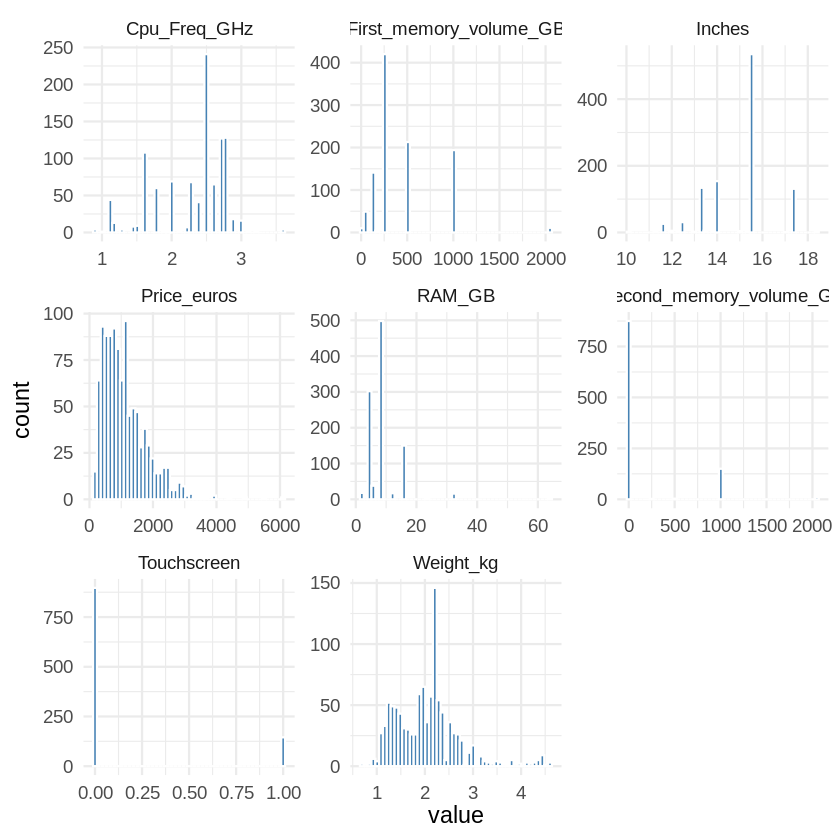

In [59]:
df %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything()) %>%
  ggplot(aes(x = value)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white") +
  facet_wrap(~ name, scales = "free", ncol = 3) +
  theme_minimal(base_size = 14)

## 2- Bivariate Analysis

In [60]:
lr_plot <- function(df, col_x, col_y, leg) {
  library(ggplot2)

  # Safe formula (handles names like RAM(GB))
  formula <- as.formula(paste0("`", col_y, "` ~ `", col_x, "`"))

  model <- lm(formula, data = df)
  slope <- coef(model)[2]
  intercept <- coef(model)[1]

  eq_label <- paste0("y = ", round(slope, 1), "x + ", round(intercept, 1))

  p <- ggplot(df, aes(x = .data[[col_x]], y = .data[[col_y]])) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE, color = "#0d98ba") +
    labs(title = paste(col_y, "VS", col_x)) +
    annotate("text",
             x = Inf, y = Inf,
             label = eq_label,
             hjust = 1.1, vjust = 1.5)

  print(p)

  return(list(slope = slope, intercept = intercept))
}

`geom_smooth()` using formula = 'y ~ x'


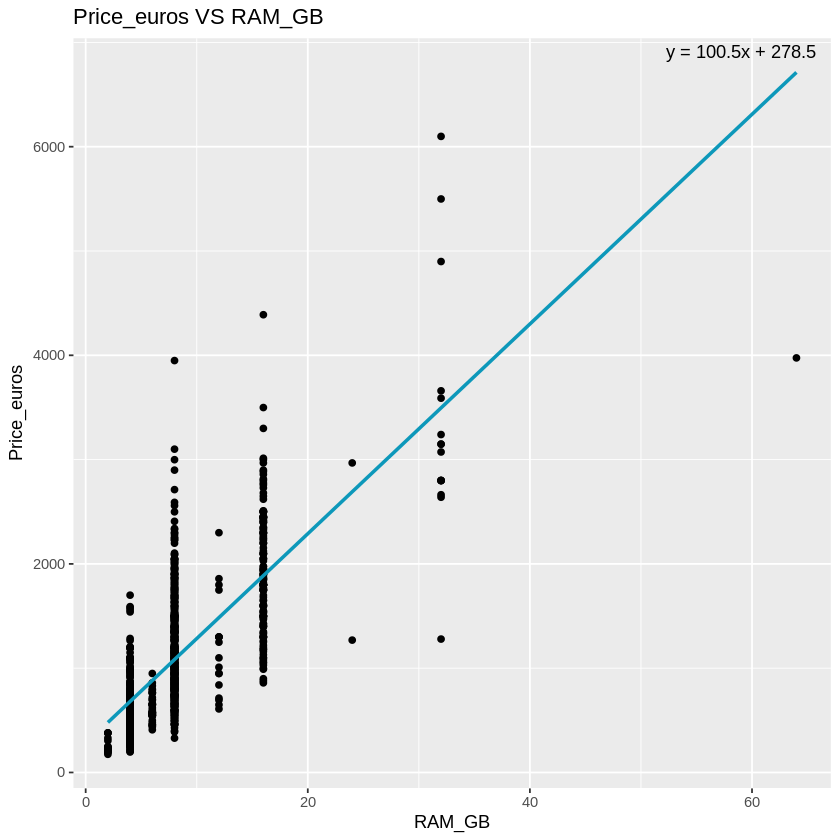

In [61]:
result <- lr_plot(df, "RAM_GB", "Price_euros", "lower right")

slope <- result$slope
intercept <- result$intercept

`geom_smooth()` using formula = 'y ~ x'


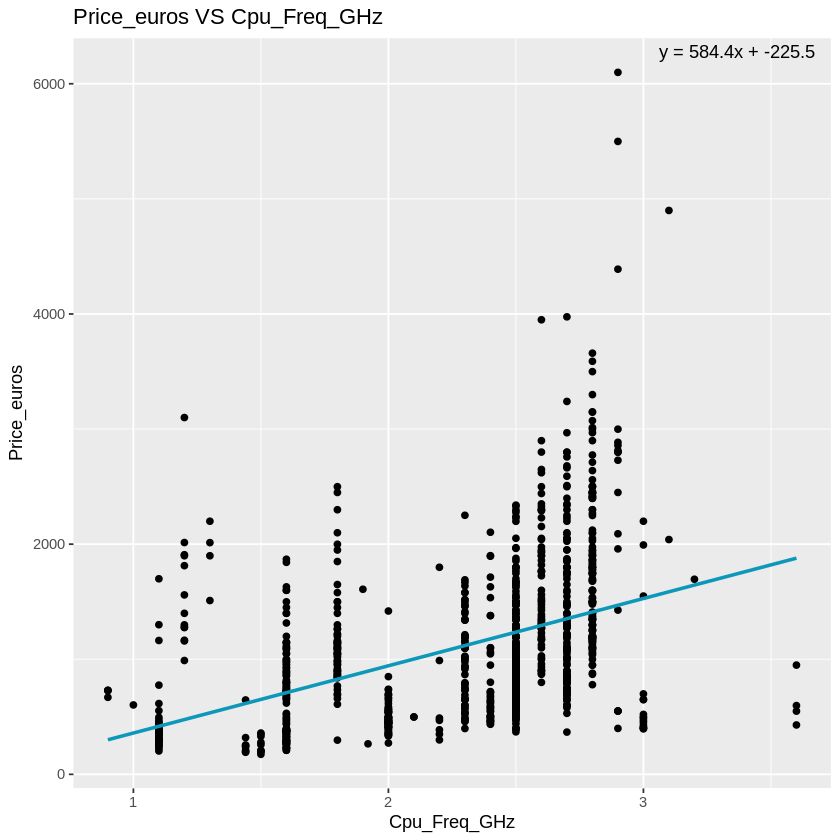

In [62]:
result <- lr_plot(df, "Cpu_Freq_GHz", "Price_euros", "lower right")

slope <- result$slope
intercept <- result$intercept

`geom_smooth()` using formula = 'y ~ x'


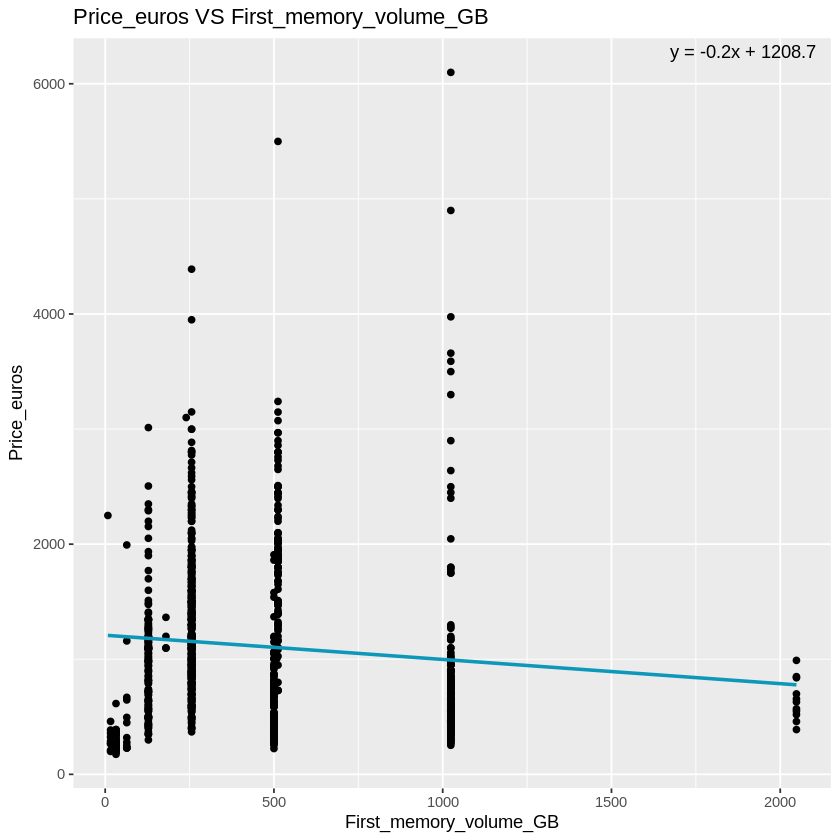

In [63]:
result <- lr_plot(df, "First_memory_volume_GB", "Price_euros", "lower right")

slope <- result$slope
intercept <- result$intercept

`geom_smooth()` using formula = 'y ~ x'


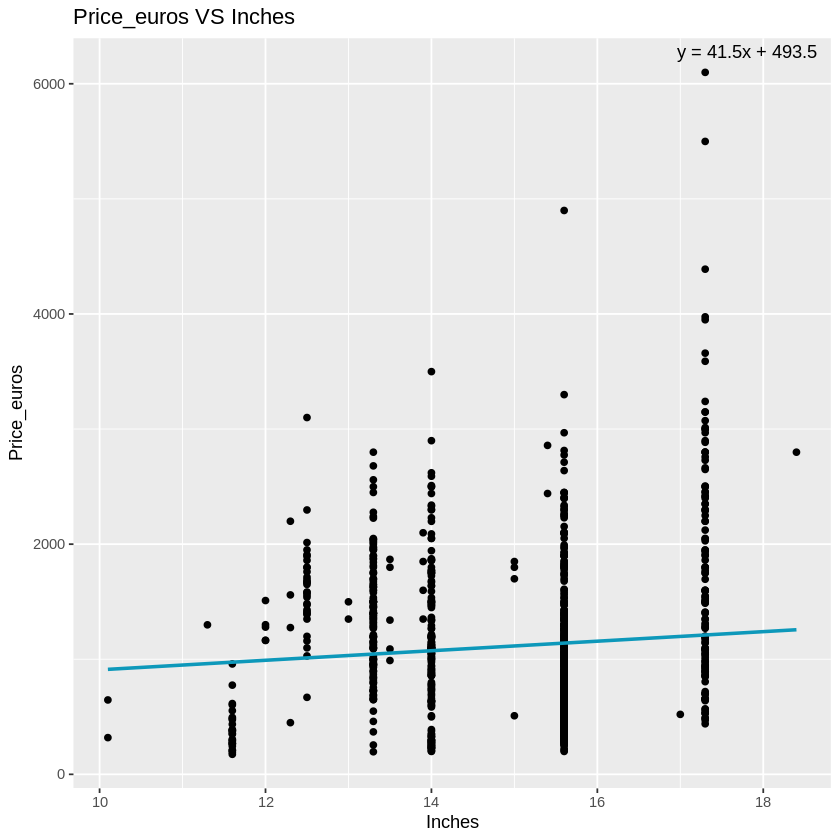

In [64]:
result <- lr_plot(df, "Inches", "Price_euros", "lower right")

slope <- result$slope
intercept <- result$intercept

`geom_smooth()` using formula = 'y ~ x'


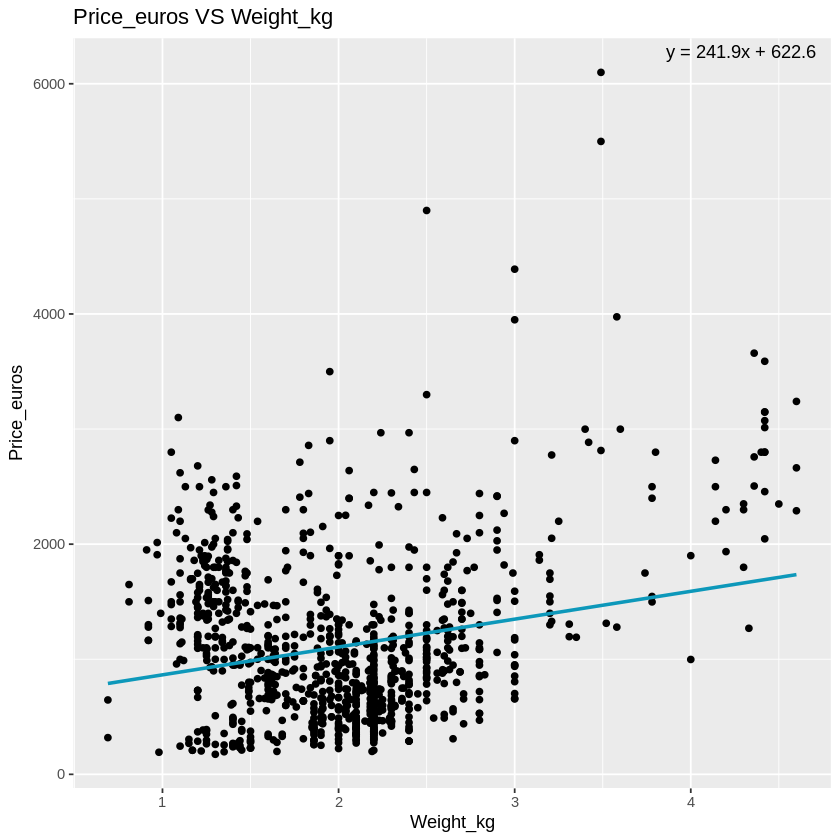

In [65]:
result <- lr_plot(df, "Weight_kg", "Price_euros", "lower right")

slope <- result$slope
intercept <- result$intercept

`geom_smooth()` using formula = 'y ~ x'


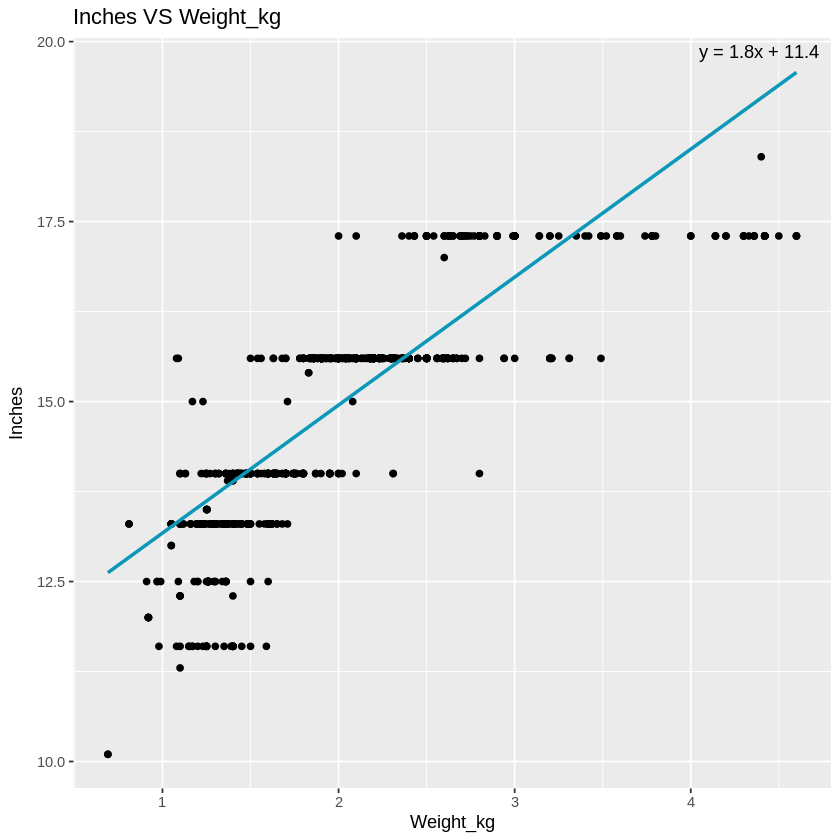

In [66]:
result <- lr_plot(df, "Weight_kg", "Inches", "lower right")

slope <- result$slope
intercept <- result$intercept

  ## 3- Multivariate Analysis

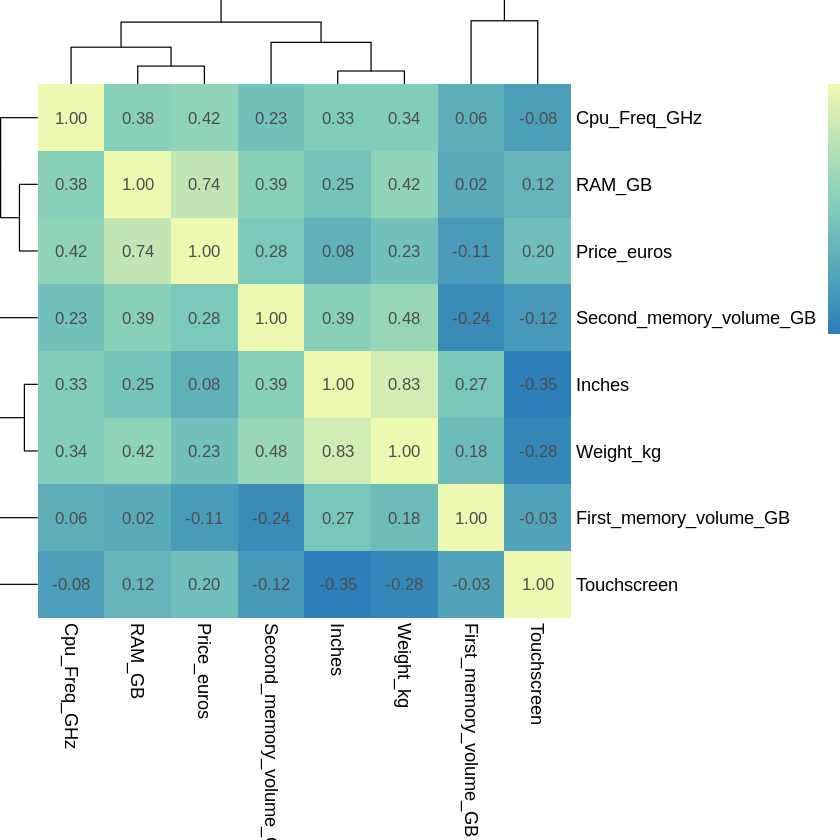

In [67]:
library(dplyr)
library(pheatmap)

# Select numeric columns
numerical_cols <- df %>% select(where(is.numeric))

# Correlation matrix
correlation_matrix <- cor(numerical_cols, use = "complete.obs")

# Heatmap (bigger + clearer)
pheatmap(
  correlation_matrix,
  display_numbers = TRUE,
  number_format = "%.2f",
  color = colorRampPalette(c("#2c7fb8", "#7fcdbb", "#edf8b1"))(100),
  main = "Correlation Heatmap",

  # 🔥 Make it larger / more readable
  cellwidth = 40,
  cellheight = 40,

  # Font tuning
  fontsize = 12,
  fontsize_number = 10,
  fontsize_row = 11,
  fontsize_col = 11,

  border_color = NA
)


Note: We will drop the "inches" feature due to the high correlation coefficient and high positive linearity between it and the "weight" feature and the non linear relation between "inches" feature and the price

In [68]:
train_set$Inches <- NULL
test_set$Inches <- NULL

head(train_set)

,Company,TypeName,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,RAM_GB,First_memory_volume_GB,First_memory_type,Second_memory_volume_GB,Gpu_company,Gpu_Type,OpSys,Weight_kg,Resolution,Touchscreen,Price_euros
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Acer,2 in 1 Convertible,Intel,Celeron Dual Core N3350,2.0,4,32,Flash Storage,0,Intel,HD Graphics 500,Windows 10,1.25,1920x1080,1,349
2,HP,Notebook,Intel,Core i7 7500U,2.7,8,256,SSD,0,Intel,HD Graphics 620,Windows 10,1.48,1920x1080,0,1292
3,Lenovo,Notebook,Intel,Core i7 6500U,2.5,4,1024,Hybrid,0,Intel,HD Graphics 520,Windows 7,2.32,1920x1080,0,825
4,MSI,Gaming,Intel,Core i7 6700HQ,2.6,8,256,SSD,0,Nvidia,GeForce GTX 965M,Windows 10,2.60,1920x1080,0,1599
5,Lenovo,Notebook,Intel,Core i3 6100U,2.3,6,128,SSD,0,Nvidia,GeForce 920MX,Windows 10,2.40,1920x1080,0,569
6,MSI,Gaming,Intel,Core i7 7500U,2.7,8,1024,HDD,0,Nvidia,GeForce GTX 1050,Windows 10,2.20,1920x1080,0,839


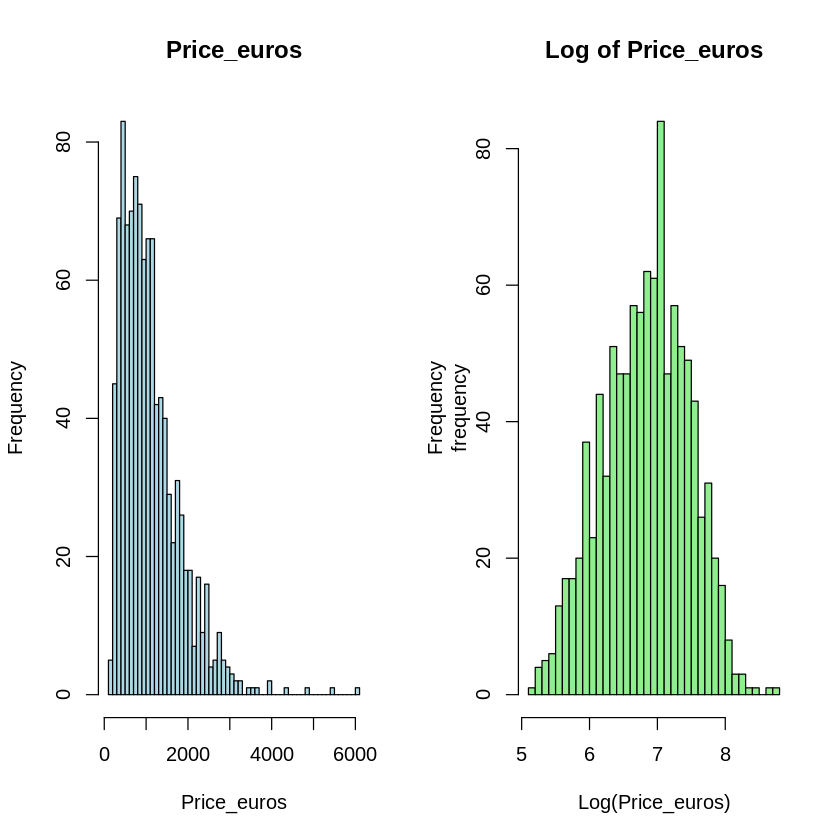

In [69]:
par(mfrow = c(1, 2))

hist(df$Price_euros,
     breaks = 50,
     main = "Price_euros",
     xlab = "Price_euros",
     col = "lightblue")

hist(log(df$Price_euros),
     breaks = 50,
     main = "Log of Price_euros",
     xlab = "Log(Price_euros)",
     col = "lightgreen")

mtext("frequency", side = 2, line = 2)

# Machine Learning


### 1- Transformation pipeline (encoding and feature scaling)

In [70]:
# Split features and target
X_train <- subset(train_set, select = -Price_euros)
y_train <- train_set$Price_euros

X_test <- subset(test_set, select = -Price_euros)
y_test <- test_set$Price_euros

# Log transformation
y_train <- log(y_train)
y_test <- log(y_test)

In [71]:
library(dplyr)
numerical_features <- c(
  'Cpu_Freq_GHz', 'RAM_GB', 'First_memory_volume_GB',
  'Second_memory_volume_GB', 'Weight_kg', 'Touchscreen'
)

categorical_features <- c(
  'Company', 'TypeName', 'Cpu_Company', 'Cpu_Type',
  'First_memory_type', 'Gpu_company', 'Gpu_Type',
  'OpSys', 'Resolution'
)

X_train <- train_set %>% select(-Price_euros)
y_train <- train_set$Price_euros

X_test <- test_set %>% select(-Price_euros)
y_test <- test_set$Price_euros

num_means <- sapply(X_train[numerical_features], mean, na.rm = TRUE)
num_sds   <- sapply(X_train[numerical_features], sd, na.rm = TRUE)

scale_numeric <- function(df, cols, means, sds) {
  df[cols] <- scale(df[cols], center = means, scale = sds)
  df
}

X_train <- scale_numeric(X_train, numerical_features, num_means, num_sds)
X_test  <- scale_numeric(X_test, numerical_features, num_means, num_sds)

ordinal_encode <- function(train, test, cols) {
  for (col in cols) {
    levels <- unique(train[[col]])

    train[[col]] <- match(train[[col]], levels)
    test[[col]]  <- match(test[[col]], levels)

    # handle unknown categories
    test[[col]][is.na(test[[col]])] <- -1
  }
  list(train = train, test = test)
}

encoded <- ordinal_encode(X_train, X_test, categorical_features)

x_train_preprocessed <- encoded$train
x_test_preprocessed  <- encoded$test

head(x_train_preprocessed)

,Company,TypeName,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,RAM_GB,First_memory_volume_GB,First_memory_type,Second_memory_volume_GB,Gpu_company,Gpu_Type,OpSys,Weight_kg,Resolution,Touchscreen
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<dbl>
1,1,1,1,1,-0.581329099,-0.83193365,-1.1365125,1,-0.4189857,1,1,1,-1.1898181,1,2.4860149
2,2,2,1,2,0.792509175,-0.06410826,-0.5108141,2,-0.4189857,1,2,1,-0.8439615,1,-0.4018642
3,3,2,1,3,0.399983954,-0.83193365,1.6344377,3,-0.4189857,1,3,2,0.4191667,1,-0.4018642
4,4,3,1,4,0.596246565,-0.06410826,-0.5108141,2,-0.4189857,2,4,1,0.8402094,1,-0.4018642
5,3,2,1,5,0.007458733,-0.44802096,-0.8683560,2,-0.4189857,2,5,1,0.5394646,1,-0.4018642
6,4,3,1,2,0.792509175,-0.06410826,1.6344377,4,-0.4189857,2,6,1,0.2387198,1,-0.4018642


### Correlation_Matrix after Encoding and scaling

In [72]:
x_train_preprocessed_df <- as.data.frame(x_train_preprocessed)
colnames(x_train_preprocessed_df) <- colnames(x_train_preprocessed)
x_train_preprocessed_df$Price_euros <- y_train
head(x_train_preprocessed_df)

,Company,TypeName,Cpu_Company,Cpu_Type,Cpu_Freq_GHz,RAM_GB,First_memory_volume_GB,First_memory_type,Second_memory_volume_GB,Gpu_company,Gpu_Type,OpSys,Weight_kg,Resolution,Touchscreen,Price_euros
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>
1,1,1,1,1,-0.581329099,-0.83193365,-1.1365125,1,-0.4189857,1,1,1,-1.1898181,1,2.4860149,349
2,2,2,1,2,0.792509175,-0.06410826,-0.5108141,2,-0.4189857,1,2,1,-0.8439615,1,-0.4018642,1292
3,3,2,1,3,0.399983954,-0.83193365,1.6344377,3,-0.4189857,1,3,2,0.4191667,1,-0.4018642,825
4,4,3,1,4,0.596246565,-0.06410826,-0.5108141,2,-0.4189857,2,4,1,0.8402094,1,-0.4018642,1599
5,3,2,1,5,0.007458733,-0.44802096,-0.8683560,2,-0.4189857,2,5,1,0.5394646,1,-0.4018642,569
6,4,3,1,2,0.792509175,-0.06410826,1.6344377,4,-0.4189857,2,6,1,0.2387198,1,-0.4018642,839


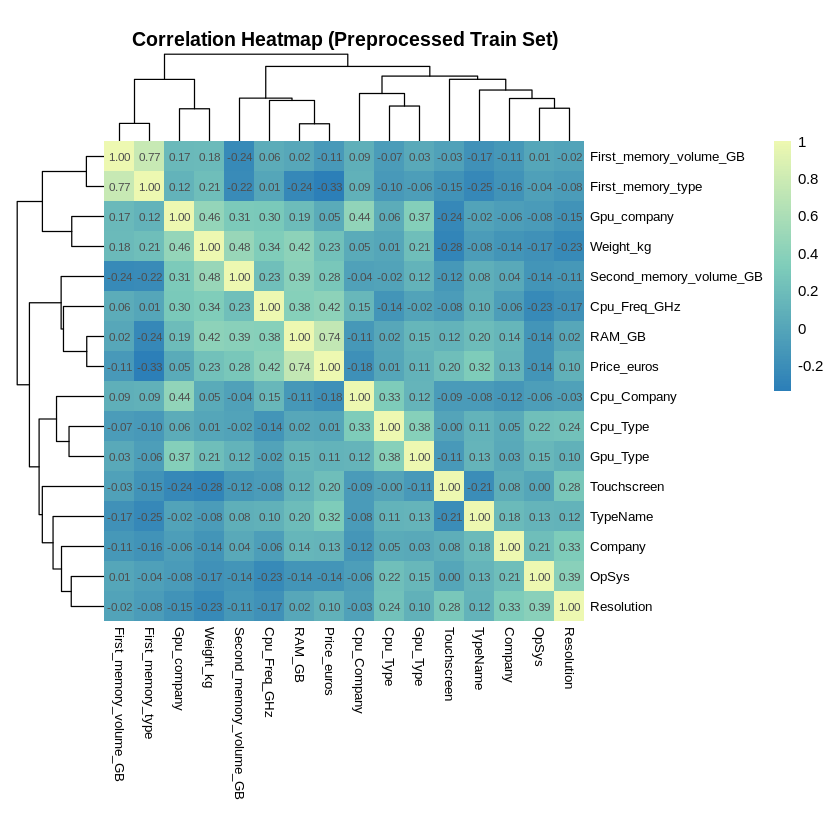

In [73]:
library(pheatmap)

correlation_matrix <- cor(x_train_preprocessed_df, use = "complete.obs")

pheatmap(
  correlation_matrix,
  display_numbers = TRUE,
  number_format = "%.2f",
  color = colorRampPalette(c("#2c7fb8", "#7fcdbb", "#edf8b1"))(100),
  main = "Correlation Heatmap (Preprocessed Train Set)",

  cellwidth = 18,
  cellheight = 18,

  fontsize = 9,
  fontsize_number = 7,
  fontsize_row = 8,
  fontsize_col = 8,

  border_color = NA
)

### 2- Select and train a model

In [74]:
y_train <- as.vector(y_train)

In [86]:
library(e1071)
library(randomForest)

models <- list(
  "Linear Regression" = "lm",
  "SVM" = "svm",
  "Random Forest" = "rf"
)

results <- list()

for (name in names(models)) {

  cat("Training", name, "...\n")

  if (name == "Linear Regression") {
    model <- lm(Price_euros ~ ., data = x_train_preprocessed_df)

  } else if (name == "SVM") {
    model <- svm(Price_euros ~ ., data = x_train_preprocessed_df)

  } else if (name == "Random Forest") {
    model <- randomForest(Price_euros ~ ., data = x_train_preprocessed_df, seed = 42)
  }

  # predictions (log scale)
  y_train_pred <- predict(model, x_train_preprocessed_df)

  # TRUE values (log scale already)
  y_train_true <- x_train_preprocessed_df$Price_euros

  # metrics in log space (same as Python)
  mse_train <- mean((y_train_true - y_train_pred)^2)
  rmse_train <- sqrt(mse_train)
  r2_train <- cor(y_train_true, y_train_pred)^2

  results[[name]] <- list(
    RMSE_Train = rmse_train,
    R2_Train = r2_train
  )

  cat(name, ":\n")
  cat(" RMSE (Train):", round(rmse_train, 4), "\n")
  cat(" R2 Score (Train):", round(r2_train, 4), "\n\n")
}

cat("Training Set Evaluation Summary:\n")
for (name in names(results)) {
  cat(name,
      ": RMSE =", round(results[[name]]$RMSE_Train, 4),
      ", R2 =", round(results[[name]]$R2_Train, 4), "\n")
}

Training Linear Regression ...
Linear Regression :
 RMSE (Train): 406.3985 
 R2 Score (Train): 0.6701 

Training SVM ...
SVM :
 RMSE (Train): 308.1186 
 R2 Score (Train): 0.8238 

Training Random Forest ...
Random Forest :
 RMSE (Train): 147.4412 
 R2 Score (Train): 0.9617 

Training Set Evaluation Summary:
Linear Regression : RMSE = 406.3985 , R2 = 0.6701 
SVM : RMSE = 308.1186 , R2 = 0.8238 
Random Forest : RMSE = 147.4412 , R2 = 0.9617 


better evaluation using Cross validation

In [88]:
library(e1071)
library(randomForest)

set.seed(42)

folds <- sample(rep(1:10, length.out = nrow(x_train_preprocessed_df)))

results <- list()

models <- list(
  "Linear Regression" = "lm",
  "SVM" = "svm",
  "Random Forest" = "rf"
)

for (name in names(models)) {

  cat("Validating", name, "...\n")

  rmse_list <- c()
  r2_list <- c()

  for (k in 1:10) {

    train_data <- x_train_preprocessed_df[folds != k, ]
    val_data   <- x_train_preprocessed_df[folds == k, ]

    if (name == "Linear Regression") {
      model <- lm(Price_euros ~ ., data = train_data)

    } else if (name == "SVM") {
      model <- svm(Price_euros ~ ., data = train_data)

    } else if (name == "Random Forest") {
      model <- randomForest(Price_euros ~ ., data = train_data)
    }

    preds <- predict(model, val_data)

    y_true <- val_data$Price_euros

    rmse <- sqrt(mean((y_true - preds)^2))
    r2 <- cor(y_true, preds)^2

    rmse_list <- c(rmse_list, rmse)
    r2_list <- c(r2_list, r2)
  }

  results[[name]] <- list(
    RMSE_CV = mean(rmse_list),
    R2_CV = mean(r2_list)
  )

  cat(name, ":\n")
  cat(" RMSE (CV):", round(mean(rmse_list), 4), "\n")
  cat(" R2 Score (CV):", round(mean(r2_list), 4), "\n\n")
}

cat("Evaluation Summary:\n")
for (name in names(results)) {
  cat(name,
      ": RMSE (CV) =", round(results[[name]]$RMSE_CV, 4),
      ", R2 (CV) =", round(results[[name]]$R2_CV, 4), "\n")
}

Validating Linear Regression ...
Linear Regression :
 RMSE (CV): 412.7215 
 R2 Score (CV): 0.6634 

Validating SVM ...
SVM :
 RMSE (CV): 372.3928 
 R2 Score (CV): 0.7345 

Validating Random Forest ...
Random Forest :
 RMSE (CV): 291.6725 
 R2 Score (CV): 0.8384 

Evaluation Summary:
Linear Regression : RMSE (CV) = 412.7215 , R2 (CV) = 0.6634 
SVM : RMSE (CV) = 372.3928 , R2 (CV) = 0.7345 
Random Forest : RMSE (CV) = 291.6725 , R2 (CV) = 0.8384 


Note: Although the random forest has clearly overfit the data we believe it is due to the low number of instances but based on that and the cross validation score, We will be using the random forest regressor hoping for better results on the test set after hyperparameter tuning

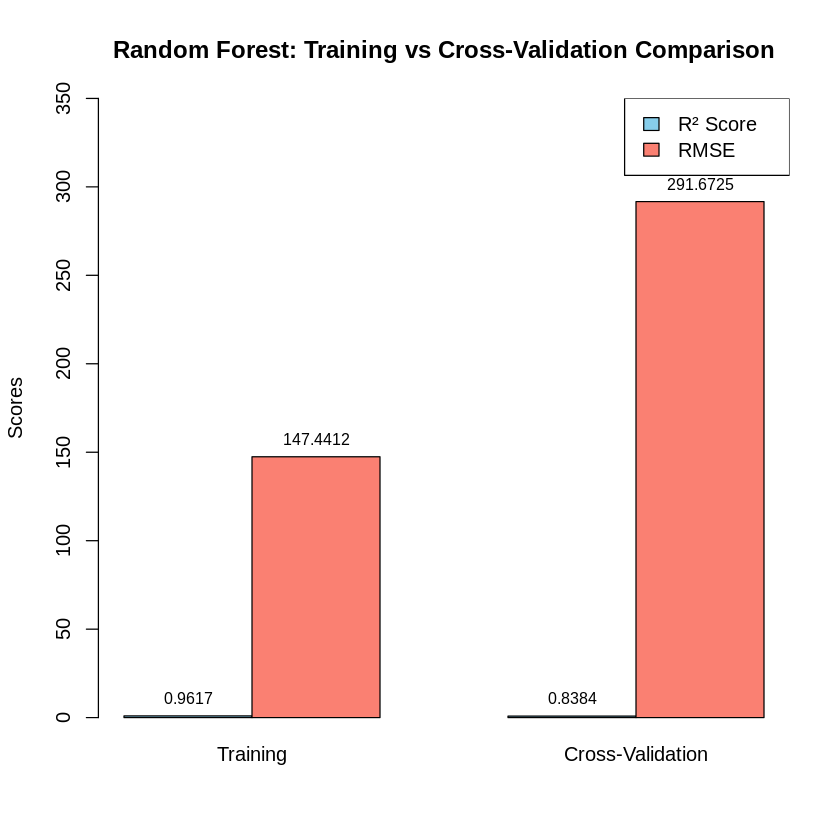

In [89]:
labels <- c("Training", "Cross-Validation")

# Extract Random Forest results (RMSE)
r2_scores_randomforest <- c(
  r2_train,
  results[["Random Forest"]]$R2_CV
)

rmse_scores_randomforest <- c(
  rmse_train,
  results[["Random Forest"]]$RMSE_CV
)

# Create barplot
x <- barplot(
  rbind(r2_scores_randomforest, rmse_scores_randomforest),
  beside = TRUE,
  names.arg = labels,
  col = c("skyblue", "salmon"),
  ylim = c(0, max(c(r2_scores_randomforest, rmse_scores_randomforest)) * 1.2),
  main = "Random Forest: Training vs Cross-Validation Comparison",
  ylab = "Scores"
)

# Legend
legend(
  "topright",
  legend = c("R² Score", "RMSE"),
  fill = c("skyblue", "salmon")
)

# Value labels
text(
  x,
  rbind(r2_scores_randomforest, rmse_scores_randomforest),
  labels = round(rbind(r2_scores_randomforest, rmse_scores_randomforest), 4),
  pos = 3,
  cex = 0.8
)

##3-hyperparamater tuning

In [91]:
library(randomForest)

set.seed(42)

param_grid <- expand.grid(
  n_estimators = c(50, 100, 200),
  nodesize = c(1, 2, 4),
  mtry = c(3, 5, 7),        # must be valid numbers
  bootstrap = c(TRUE, FALSE)
)

results <- data.frame()

folds <- sample(rep(1:5, length.out = nrow(x_train_preprocessed_df)))

p <- ncol(x_train_preprocessed_df) - 1  # number of features

for (i in 1:nrow(param_grid)) {

  params <- param_grid[i, ]

  rmse_list <- c()
  r2_list <- c()

  for (k in 1:5) {

    train_data <- x_train_preprocessed_df[folds != k, ]
    val_data   <- x_train_preprocessed_df[folds == k, ]

    model <- randomForest(
      Price_euros ~ .,
      data = train_data,
      ntree = params$n_estimators,
      mtry = min(params$mtry, p),   # prevent invalid mtry
      nodesize = params$nodesize,
      replace = params$bootstrap
    )

    preds <- predict(model, val_data)

    y_true <- val_data$Price_euros

    rmse <- sqrt(mean((y_true - preds)^2))
    r2 <- cor(y_true, preds)^2

    rmse_list <- c(rmse_list, rmse)
    r2_list <- c(r2_list, r2)
  }

  results <- rbind(results, data.frame(
    n_estimators = params$n_estimators,
    mtry = params$mtry,
    nodesize = params$nodesize,
    bootstrap = params$bootstrap,
    RMSE = mean(rmse_list),
    R2 = mean(r2_list)
  ))
}

best_model <- results[which.max(results$R2), ]

cat("\nBest Hyperparameters:\n")
print(best_model)


Best Hyperparameters:
  n_estimators mtry nodesize bootstrap     RMSE        R2
3          200    3        1      TRUE 290.4509 0.8406392


Finalmodel=RandomForestRegressor

In [92]:
library(randomForest)

set.seed(42)

best_rf_model <- randomForest(
  Price_euros ~ .,
  data = x_train_preprocessed_df,
  ntree = 200,        # n_estimators
  nodesize = 1,       # min_samples_leaf
  mtry = floor(sqrt(ncol(x_train_preprocessed_df) - 1)),  # default behavior
  replace = TRUE      # bootstrap = True
)

# Model summary (optional)
print(best_rf_model)


Call:
 randomForest(formula = Price_euros ~ ., data = x_train_preprocessed_df,      ntree = 200, nodesize = 1, mtry = floor(sqrt(ncol(x_train_preprocessed_df) -          1)), replace = TRUE) 
               Type of random forest: regression
                     Number of trees: 200
No. of variables tried at each split: 3

          Mean of squared residuals: 87325.62
                    % Var explained: 82.56


## 4- Testing

In [93]:
# Make predictions on the test set
y_pred <- predict(best_rf_model, x_test_preprocessed)

# True values
y_true <- y_test

# RMSE
rmse <- sqrt(mean((y_true - y_pred)^2))

# R² score
r2 <- cor(y_true, y_pred)^2

cat(sprintf("Test Set Performance: RMSE = %.4f, R² = %.4f\n", rmse, r2))

Test Set Performance: RMSE = 217.0954, R² = 0.8986


# Insights and Findings

1. RAM is one of the strongest price drivers

Laptops with higher RAM (especially 16GB and above) show a clear increase in price compared to lower RAM configurations (4GB–8GB). This indicates that memory capacity is a key factor in determining laptop value and targeting high-performance users.

2. Brand has a significant impact on pricing

Certain companies (such as premium brands ex: Apple) consistently show higher average prices, even when specifications are similar. This suggests that brand reputation and market positioning play a major role in pricing strategy.

3. Storage type affects price more than storage size

Laptops with SSD storage tend to be more expensive than those with HDD, even when the total storage capacity is lower. This shows that performance (speed) is valued more than raw storage space.

4. High-end CPUs are associated with higher prices

Devices equipped with more powerful processors (e.g., newer generations or higher tiers) generally fall into higher price ranges. This confirms that CPU performance is a key contributor to laptop cost.

5. Gaming / high-performance laptops form a distinct segment

Laptops designed for gaming or heavy performance tasks tend to cluster in the higher price range, reflecting their advanced specifications (GPU, RAM, cooling systems).

6. Correlation analysis confirms key drivers

The correlation matrix shows that RAM, CPU, and storage type have the strongest positive relationships with price, while other features (like weight) have minimal impact

# Conclusion

This project analyzed a laptop dataset to identify the key factors influencing laptop prices and to better understand market patterns. Through data cleaning and exploratory data analysis, several important relationships were revealed. The results showed that technical specifications such as RAM, CPU performance, storage type, and GPU play a major role in determining laptop prices, with higher-end components consistently associated with higher costs. In addition, brand reputation was found to significantly influence pricing, as some companies charge a premium regardless of similar specifications.

The analysis also highlighted that certain features, such as weight, have minimal impact on price, while others like SSD storage and display quality contribute more strongly to price variation. Furthermore, the distribution of prices indicated that most laptops fall within a mid-range category, with fewer high-end devices creating a right-skewed distribution.

Overall, this analysis provides valuable insights into how different features and brand positioning affect laptop pricing. These findings can help consumers make more informed purchasing decisions and assist businesses in understanding competitive pricing strategies.